In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [ ]:
car = pd.read_csv("/content/car data.csv")


In [ ]:
car.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
car.shape

(301, 9)

In [ ]:
car.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


In [ ]:
car.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

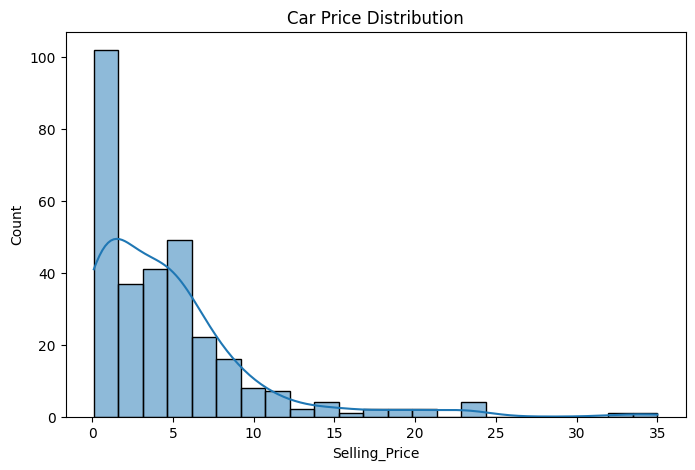

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    car['Selling_Price'],
    kde=True
)

plt.title("Car Price Distribution")

plt.show()

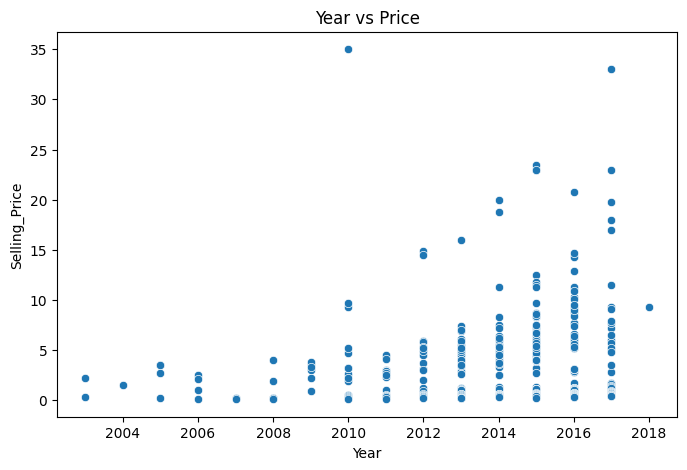

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Year',
    y='Selling_Price',
    data=car
)

plt.title("Year vs Price")

plt.show()

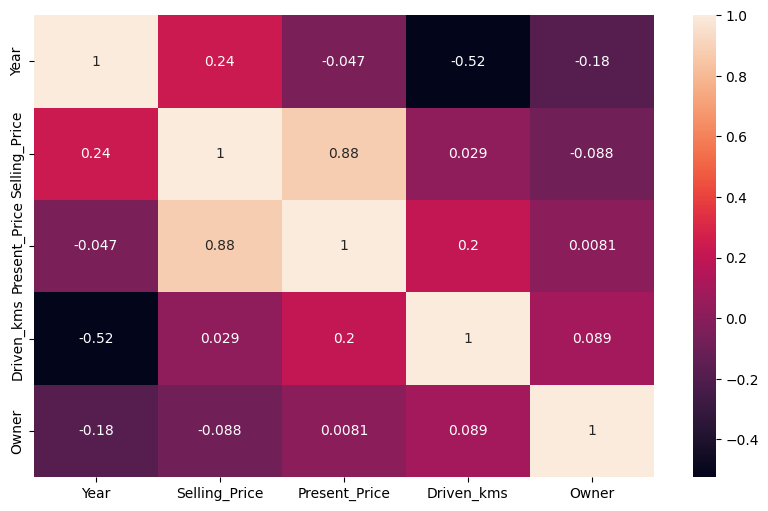

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    car.corr(numeric_only=True),
    annot=True
)

plt.show()

In [ ]:
features = [
    'Year',
    'Driven_kms',
    'Fuel_Type',
    'Selling_type',
    'Transmission',
    'Owner'
]


X = car[features].copy()

y = car['Selling_Price']

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in X.select_dtypes(include='object').columns:
    X[col] = encoder.fit_transform(X[col])

In [ ]:
X.head()

,Year,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,2014,27000,2,0,1,0
1,2013,43000,1,0,1,0
2,2017,6900,2,0,1,0
3,2011,5200,2,0,1,0
4,2014,42450,1,0,1,0


In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)


model.fit(
    X_train,
    y_train
)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred = model.predict(
    X_test
)

In [ ]:
result = pd.DataFrame({

"Actual": y_test,

"Predicted": y_pred

})


result.head()

,Actual,Predicted
177,0.35,0.5237
289,10.11,4.8726
228,4.95,6.4855
198,0.15,0.2897
60,6.95,4.7455


In [ ]:
print(
"MAE:",
mean_absolute_error(
y_test,
y_pred
)
)


print(
"MSE:",
mean_squared_error(
y_test,
y_pred
)
)


print(
"R2 Score:",
r2_score(
y_test,
y_pred
)
)

MAE: 1.1418428376268541
MSE: 3.7928394262529506
R2 Score: 0.8353486787838122


In [ ]:
car = [[
2020,
30000,
1,
1,
1,
0
]]


price = model.predict(car)


print(
"Estimated Car Price:",
price[0]
)

Estimated Car Price: 10.8607


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:
joblib.dump(
    model,
    "car_price_model.pkl"
)

['car_price_model.pkl']

In [ ]:
from google.colab import files

files.download(
"car_price_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>